<a href="https://colab.research.google.com/github/e23106-eng/Statistical-Learning-e23106/blob/main/Assignment_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [20]:
import json, csv
import pandas as pd
import networkx as nx
import graphviz
from IPython.display import display, Image, HTML

from pydantic import BaseModel, ValidationError, field_validator
from typing import Optional

In [49]:
!pip install "git+https://github.com/e23106-eng/Statistical-Learning-e23106.git"

  Cloning https://github.com/e23106-eng/Statistical-Learning-e23106.git to /tmp/pip-req-build-f98am_9z
  Running command git clone --filter=blob:none --quiet https://github.com/e23106-eng/Statistical-Learning-e23106.git /tmp/pip-req-build-f98am_9z
  Resolved https://github.com/e23106-eng/Statistical-Learning-e23106.git to commit 4389a9908c394b9dc029bb84ea67c844923098b0
  Preparing metadata (setup.py) ... done


In [52]:
# Manual setup to fix the 'dara inspector' folder name issue
import os, sys

repo_name = 'Statistical-Learning-e23106'
incorrect_package_path = os.path.join(repo_name, 'dara inspector')
correct_package_path = os.path.join(repo_name, 'data_inspector')

if not os.path.exists(repo_name):
    print(f"Cloning {repo_name} from GitHub...")
    !git clone https://github.com/e23106-eng/Statistical-Learning-e23106.git
else:
    print(f"{repo_name} already exists. Pulling latest updates...")
    !cd {repo_name} && git pull

# Check if the problematic folder exists and rename it
if os.path.exists(incorrect_package_path):
    print(f"Found incorrect package folder: '{incorrect_package_path}'. Renaming to '{correct_package_path}'...")
    os.rename(incorrect_package_path, correct_package_path)
    print("Rename successful.")
elif not os.path.exists(correct_package_path):
    print(f"Warning: Neither '{incorrect_package_path}' nor '{correct_package_path}' found. Package might be missing.")

# Add the cloned repository's base directory to sys.path
# This allows direct import of 'data_inspector' after renaming
sys.path.insert(0, os.path.abspath(repo_name))

print("Setup complete. You should now be able to import 'data_inspector'.")

Statistical-Learning-e23106 already exists. Pulling latest updates...
remote: Enumerating objects: 3, done.
remote: Counting objects: 100% (3/3), done.
remote: Compressing objects: 100% (1/1), done.
remote: Total 2 (delta 1), reused 2 (delta 1), pack-reused 0 (from 0)
Unpacking objects: 100% (2/2), 221 bytes | 221.00 KiB/s, done.
From https://github.com/e23106-eng/Statistical-Learning-e23106
   29c384c..4389a99  main       -> origin/main
Updating 29c384c..4389a99
Fast-forward
 {dara inspector => data_inspector}/__init__.py | 0
 {dara inspector => data_inspector}/core.py     | 0
 {dara inspector => data_inspector}/plotting.py | 0
 3 files changed, 0 insertions(+), 0 deletions(-)
 rename {dara inspector => data_inspector}/__init__.py (100%)
 rename {dara inspector => data_inspector}/core.py (100%)
 rename {dara inspector => data_inspector}/plotting.py (100%)
Setup complete. You should now be able to import 'data_inspector'.


In [54]:
from data_inspector import DataInspector, PlottingMethods

In [60]:
import pandas as pd
from data_inspector import DataInspector
inspector = DataInspector()

# Initialize and Upload
inspector.upload_data()
# Alternatively use
#inspector.df=pd.read_csv('xxxx.csv')

# inspector.upload_data()
url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
inspector.df = pd.read_csv(url)

# Step 2: Extract system summaries, missing value profiles, and column configurations
# inspector.get_summary()
# inspector.column_details()
# inspector.show_missing_data()

# Step 3: Interactive targeted cleanup and removal
# inspector.delete_columns()  # Drop irrelevant feature dimensions
# inspector.delete_rows()     # Trim specific row indexes

Saving titanic_sample.csv to titanic_sample.csv
✅ Successfully loaded 'titanic_sample.csv' (20 rows, 10 columns).


In [66]:
# Introduce some synthetic garbage strings to showcase sanitisation
inspector.df.loc[0, 'Age']    = '?'
inspector.df.loc[1, 'Cabin']  = 'NULL'
inspector.df.loc[2, 'Fare']   = 'n/a'

# Re-run sanitisation manually (upload_data() does this automatically)
import numpy as np
_GARBAGE = {'?','n/a','na','null','none','nan',' ','','--','N/A','NULL','None','NaN','NA'}
inspector.df.replace(_GARBAGE, np.nan, inplace=True)
# inspector._auto_convert_types()

print(f'Dataset loaded: {inspector.df.shape[0]:,} rows × {inspector.df.shape[1]} columns')
inspector.df.head()

Dataset loaded: 891 rows × 12 columns


/tmp/ipykernel_3260/2247183214.py:2: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '?' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  inspector.df.loc[0, 'Age']    = '?'
/tmp/ipykernel_3260/2247183214.py:4: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'n/a' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  inspector.df.loc[2, 'Fare']   = 'n/a'
/tmp/ipykernel_3260/2247183214.py:9: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  inspector.df.replace(_GARBAGE, np.nan, inplace=True)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,NaN,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,NaN,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,NaN,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [69]:
# 4-A  Full summary: shape, first 20 rows, numeric & categorical stats
inspector.data_summary()

 STRUCTURAL SUMMARY: 891 Rows | 12 Columns
 Numeric Features (7): ['PassengerId', 'Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare']
 Categorical Features (5): ['Name', 'Sex', 'Ticket', 'Cabin', 'Embarked']


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,NaN,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,NaN,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,NaN,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [81]:
inspector.df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,713.000000,891.000000,891.000000,890.000000
mean,446.000000,0.383838,2.308642,29.709916,0.523008,0.381594,32.231488
std,257.353842,0.486592,0.836071,14.533827,1.102743,0.806057,49.714694
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.000000,0.000000,0.000000,7.903100
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [84]:
# 4-B  Column-level detail: dtype, nulls, unique counts
column_info = pd.DataFrame({
    'Dtype': inspector.df.dtypes,
    'Nulls': inspector.df.isnull().sum(),
    'Unique': inspector.df.nunique()
})
print(column_info)

               Dtype  Nulls  Unique
PassengerId    int64      0     891
Survived       int64      0       2
Pclass         int64      0       3
Name          object      0     891
Sex           object      0       2
Age          float64    178      88
SibSp          int64      0       7
Parch          int64      0       7
Ticket        object      0     681
Fare         float64      1     248
Cabin         object    688     146
Embarked      object      2       3


In [86]:
# 4-C  Categorical value-count tables
# inspector.get_categorical_summary() # This method does not exist

for col in inspector.df.select_dtypes(include='object').columns:
    print(f"\nValue counts for column '{col}':")
    print(inspector.df[col].value_counts())
    print("-" * 30)


Value counts for column 'Name':
Name
Dooley, Mr. Patrick                                    1
Braund, Mr. Owen Harris                                1
Cumings, Mrs. John Bradley (Florence Briggs Thayer)    1
Heikkinen, Miss. Laina                                 1
Futrelle, Mrs. Jacques Heath (Lily May Peel)           1
                                                      ..
Hewlett, Mrs. (Mary D Kingcome)                        1
Vestrom, Miss. Hulda Amanda Adolfina                   1
Andersson, Mr. Anders Johan                            1
Saundercock, Mr. William Henry                         1
Bonnell, Miss. Elizabeth                               1
Name: count, Length: 891, dtype: int64
------------------------------

Value counts for column 'Sex':
Sex
male      577
female    314
Name: count, dtype: int64
------------------------------

Value counts for column 'Ticket':
Ticket
347082              7
1601                7
CA. 2343            7
3101295             6
CA 2144       

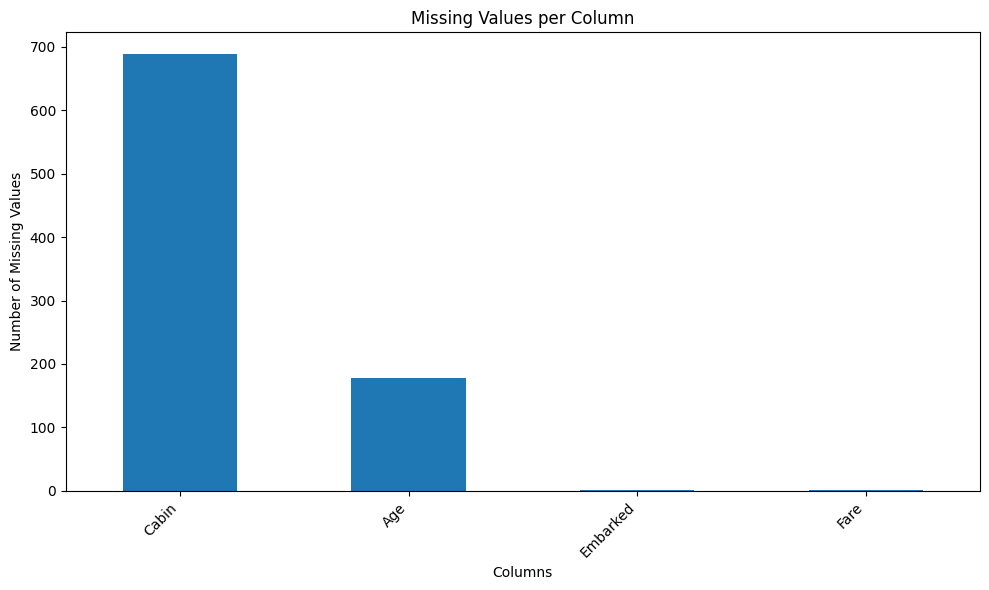

In [87]:
# 4-D  Missing-value bar chart
# inspector.show_missing_data() # This method does not exist

import matplotlib.pyplot as plt

missing_data = inspector.df.isnull().sum()
missing_data = missing_data[missing_data > 0]

if not missing_data.empty:
    plt.figure(figsize=(10, 6))
    missing_data.sort_values(ascending=False).plot(kind='bar')
    plt.title('Missing Values per Column')
    plt.xlabel('Columns')
    plt.ylabel('Number of Missing Values')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()
else:
    print("No missing values found in the DataFrame.")

In [90]:
# 4-E  Drop high-null columns that aren't useful for modelling
#      (interactive: leave blank and it will prompt; or pass a string directly)
# inspector.delete_columns(columns='Cabin, Ticket, Name')

# Using pandas to drop columns
columns_to_drop = ['Cabin', 'Ticket', 'Name']
inspector.df = inspector.df.drop(columns=columns_to_drop, errors='ignore')
print(f"Columns dropped: {columns_to_drop}. Current DataFrame shape: {inspector.df.shape}")

Columns dropped: ['Cabin', 'Ticket', 'Name']. Current DataFrame shape: (891, 9)


In [97]:
# 4-F  Impute remaining missing values
#      Age  → median  (numeric, skewed)
#      Embarked → mode  (categorical)
#      Fare → median (numeric)
# inspector.handle_missing_values(strategy='median',  columns=['Age', 'Fare'])
# inspector.handle_missing_values(strategy='mode',    columns=['Embarked'])
# inspector.show_missing_data()

# Using pandas to impute missing values

# Impute 'Age' with median
if 'Age' in inspector.df.columns and inspector.df['Age'].isnull().any():
    median_age = inspector.df['Age'].median()
    inspector.df['Age'].fillna(median_age, inplace=True)
    print(f"Missing 'Age' values imputed with median: {median_age}")
else:
    print("'Age' column not found or no missing values.")

# Impute 'Embarked' with mode
if 'Embarked' in inspector.df.columns and inspector.df['Embarked'].isnull().any():
    mode_embarked = inspector.df['Embarked'].mode()[0] # .mode() can return multiple if tied
    inspector.df['Embarked'].fillna(mode_embarked, inplace=True)
    print(f"Missing 'Embarked' values imputed with mode: {mode_embarked}")
else:
    print("'Embarked' column not found or no missing values.")

# Impute 'Fare' with median
if 'Fare' in inspector.df.columns and inspector.df['Fare'].isnull().any():
    median_fare = inspector.df['Fare'].median()
    inspector.df['Fare'].fillna(median_fare, inplace=True)
    print(f"Missing 'Fare' values imputed with median: {median_fare}")
else:
    print("'Fare' column not found or no missing values.")

# Verify remaining missing data
print("\nRemaining missing values after imputation:")
print(inspector.df.isnull().sum()[inspector.df.isnull().sum() > 0])

'Age' column not found or no missing values.
'Embarked' column not found or no missing values.
Missing 'Fare' values imputed with median: 14.4542

Remaining missing values after imputation:
Series([], dtype: int64)


/tmp/ipykernel_3260/4210916746.py:30: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  inspector.df['Fare'].fillna(median_fare, inplace=True)


In [98]:
# 4-G  Remove duplicate rows
# inspector.remove_duplicates()

initial_rows = inspector.df.shape[0]
inspector.df.drop_duplicates(inplace=True)
removed_rows = initial_rows - inspector.df.shape[0]

if removed_rows > 0:
    print(f"Removed {removed_rows} duplicate rows. New shape: {inspector.df.shape}")
else:
    print("No duplicate rows found.")

No duplicate rows found.


In [100]:
# 4-H  Outlier detection & removal via IQR
# inspector.handle_outliers(columns=['Age', 'Fare', 'SibSp', 'Parch'],
#                           find_and_delete=True)

import numpy as np

columns_for_outliers = ['Age', 'Fare', 'SibSp', 'Parch']
initial_rows = inspector.df.shape[0]

print("--- Outlier Detection and Removal (IQR Method) ---")

for col in columns_for_outliers:
    if col in inspector.df.columns and pd.api.types.is_numeric_dtype(inspector.df[col]):
        Q1 = inspector.df[col].quantile(0.25)
        Q3 = inspector.df[col].quantile(0.75)
        IQR = Q3 - Q1

        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        # Identify outliers
        outliers_mask = (inspector.df[col] < lower_bound) | (inspector.df[col] > upper_bound)
        num_outliers = outliers_mask.sum()

        if num_outliers > 0:
            print(f"Found {num_outliers} outliers in '{col}'. Removing...")
            inspector.df = inspector.df[~outliers_mask]
        else:
            print(f"No outliers found in '{col}'.")
    else:
        print(f"Column '{col}' not found or is not numeric. Skipping outlier detection.")

removed_rows = initial_rows - inspector.df.shape[0]

if removed_rows > 0:
    print(f"\nTotal {removed_rows} rows removed due to outliers.")
    print(f"New DataFrame shape: {inspector.df.shape}")
else:
    print("\nNo rows were removed due to outliers.")

--- Outlier Detection and Removal (IQR Method) ---
Found 66 outliers in 'Age'. Removing...
Found 107 outliers in 'Fare'. Removing...
Found 29 outliers in 'SibSp'. Removing...
Found 112 outliers in 'Parch'. Removing...

Total 314 rows removed due to outliers.
New DataFrame shape: (577, 9)


--- Plotting Numerical Distributions (Violin | Scatter | Histogram) ---


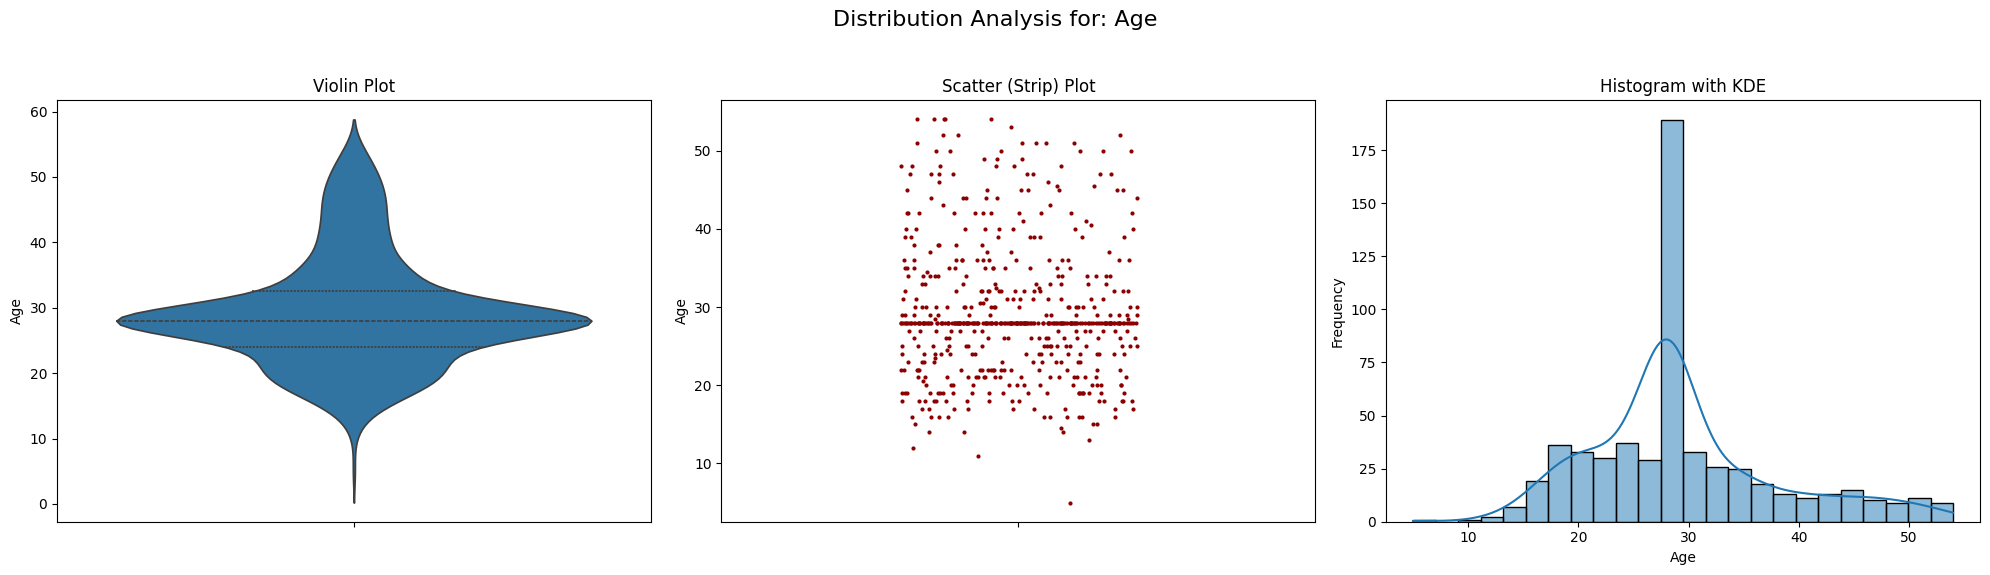

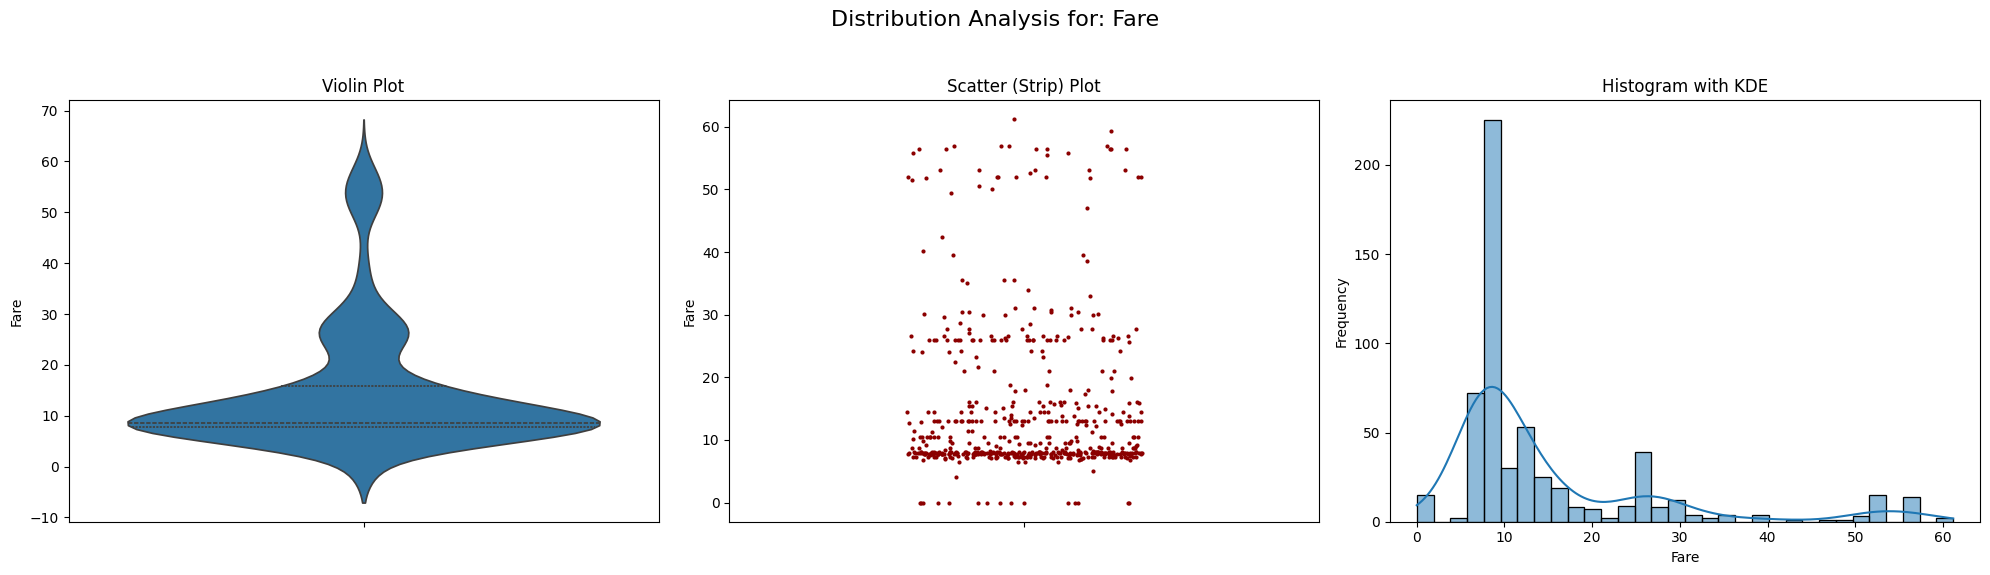

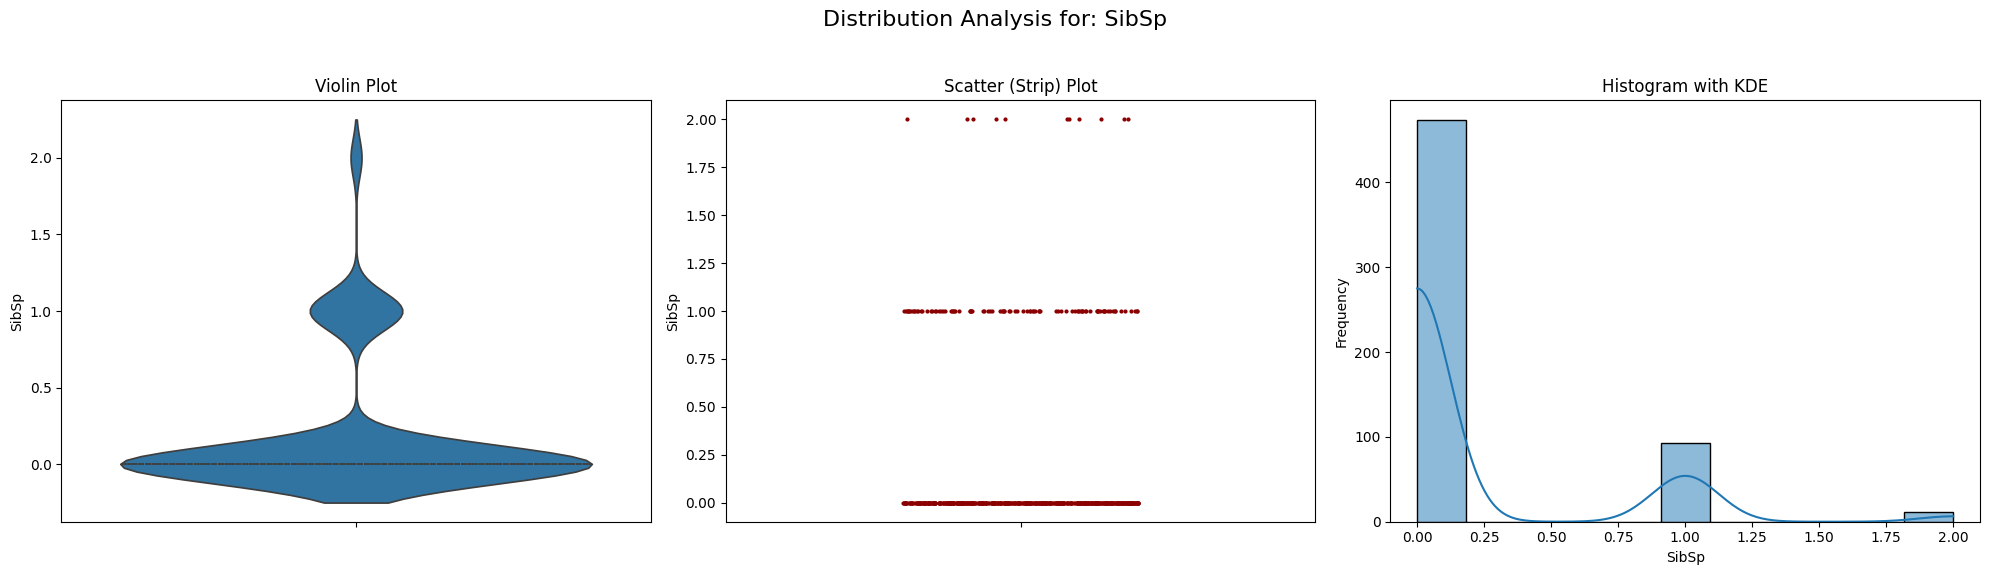

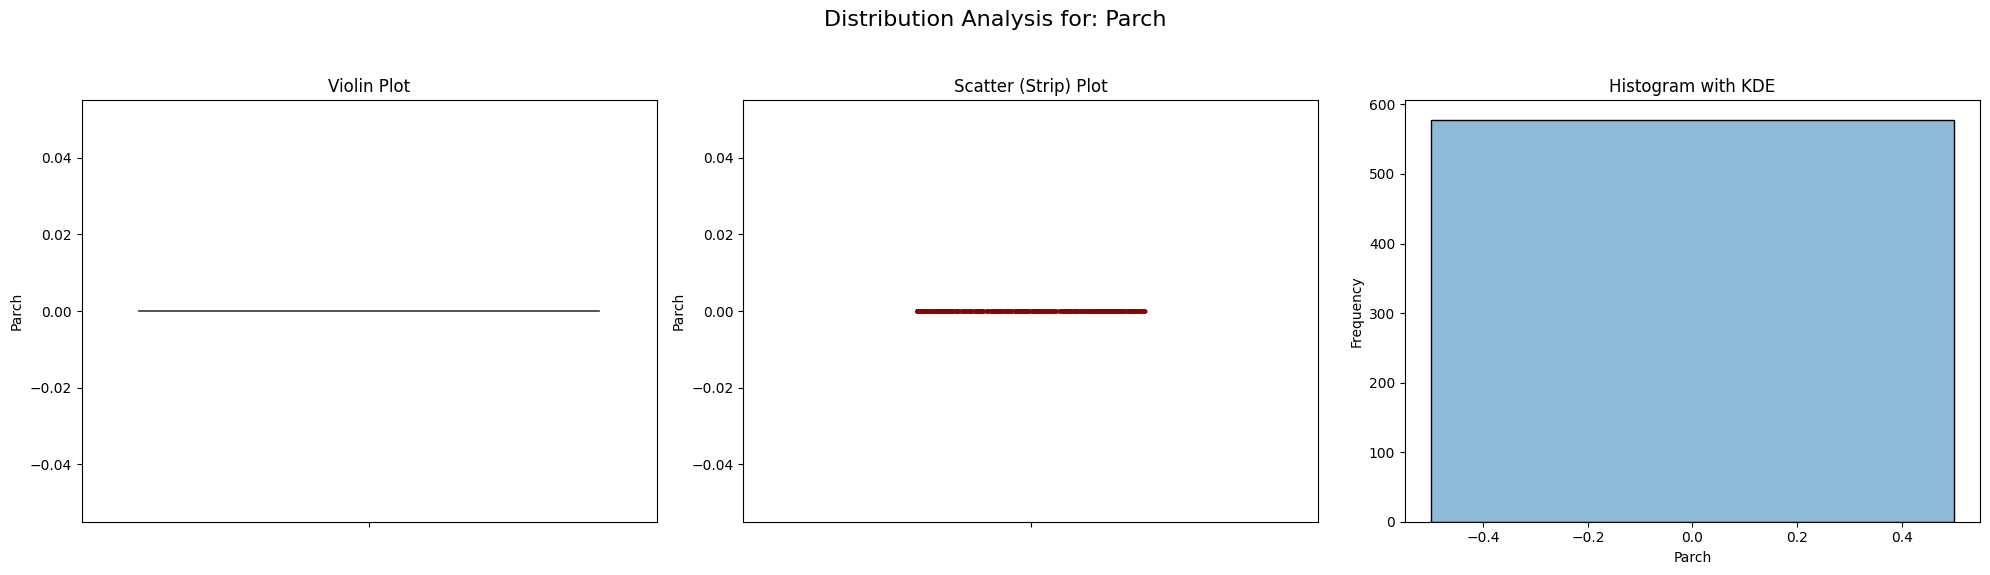

In [102]:
# 5-A  3-panel numeric subplots: Violin | Scatter | Histogram
# inspector.plot_numerical(column_names=['Age', 'Fare', 'SibSp', 'Parch'])

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd # Ensure pandas is imported for pd.api.types.is_numeric_dtype

columns_to_plot = ['Age', 'Fare', 'SibSp', 'Parch']

print("--- Plotting Numerical Distributions (Violin | Scatter | Histogram) ---")

for col in columns_to_plot:
    if col in inspector.df.columns and pd.api.types.is_numeric_dtype(inspector.df[col]):
        fig, axes = plt.subplots(1, 3, figsize=(20, 6))
        fig.suptitle(f'Distribution Analysis for: {col}', fontsize=16)

        # Plot 1: Violin Plot
        sns.violinplot(y=inspector.df[col], ax=axes[0], inner='quartile')
        axes[0].set_title('Violin Plot')
        axes[0].set_xlabel('')
        axes[0].set_ylabel(col)

        # Plot 2: Strip Plot (Scatter of individual points)
        sns.stripplot(y=inspector.df[col], ax=axes[1], jitter=0.2, color='darkred', size=3)
        axes[1].set_title('Scatter (Strip) Plot')
        axes[1].set_xlabel('')
        axes[1].set_ylabel(col)

        # Plot 3: Histogram with KDE
        sns.histplot(inspector.df[col], kde=True, ax=axes[2])
        axes[2].set_title('Histogram with KDE')
        axes[2].set_xlabel(col)
        axes[2].set_ylabel('Frequency')

        plt.tight_layout(rect=[0, 0.03, 1, 0.95])
        plt.show()
    else:
        print(f"Column '{col}' not found or is not numeric. Skipping plotting.")

--- Plotting Categorical Frequency Bar Charts ---


/tmp/ipykernel_3260/2691937394.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=inspector.df, x=col, palette='viridis')


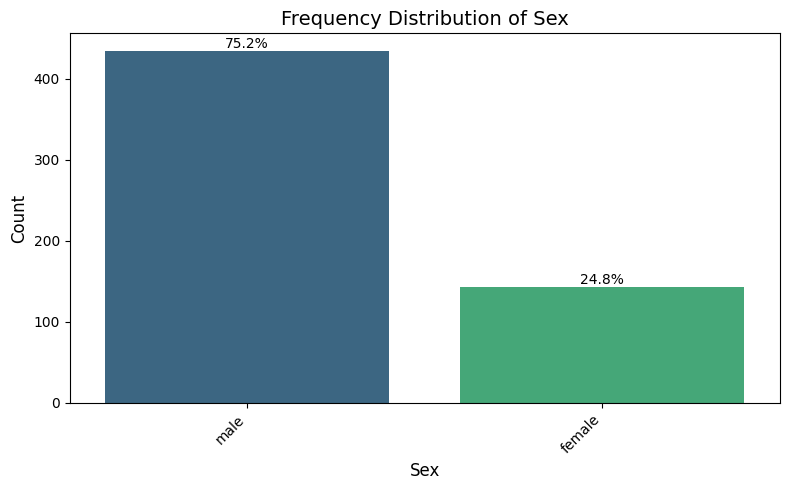

/tmp/ipykernel_3260/2691937394.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=inspector.df, x=col, palette='viridis')


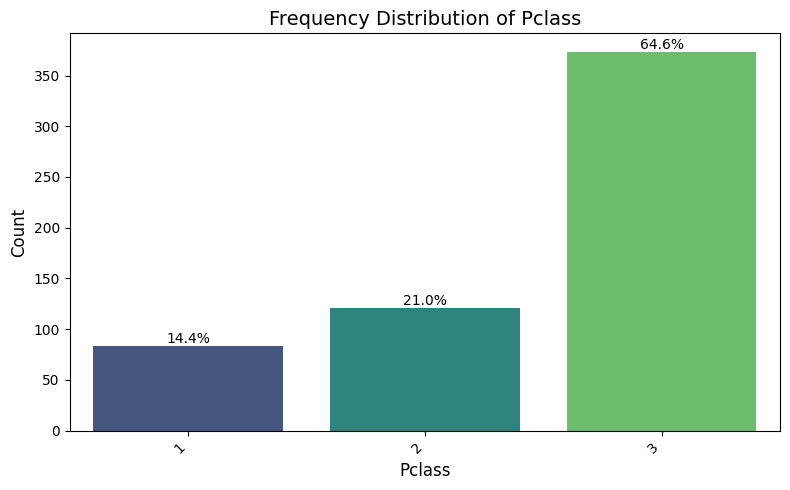

/tmp/ipykernel_3260/2691937394.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=inspector.df, x=col, palette='viridis')


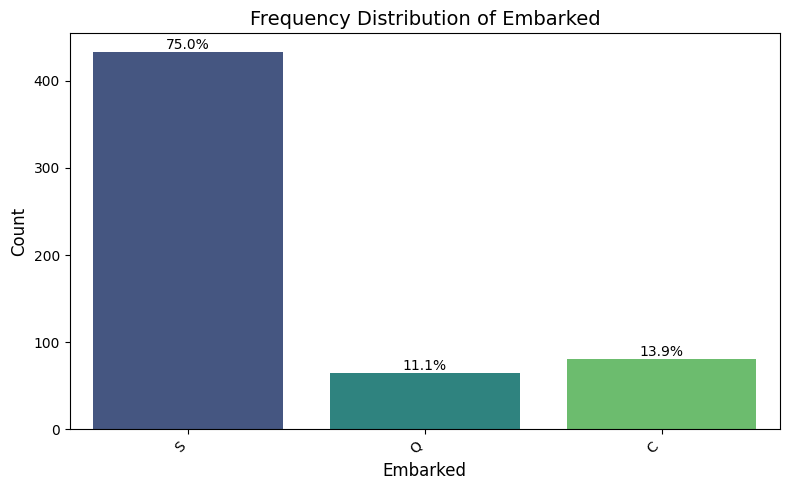

/tmp/ipykernel_3260/2691937394.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=inspector.df, x=col, palette='viridis')


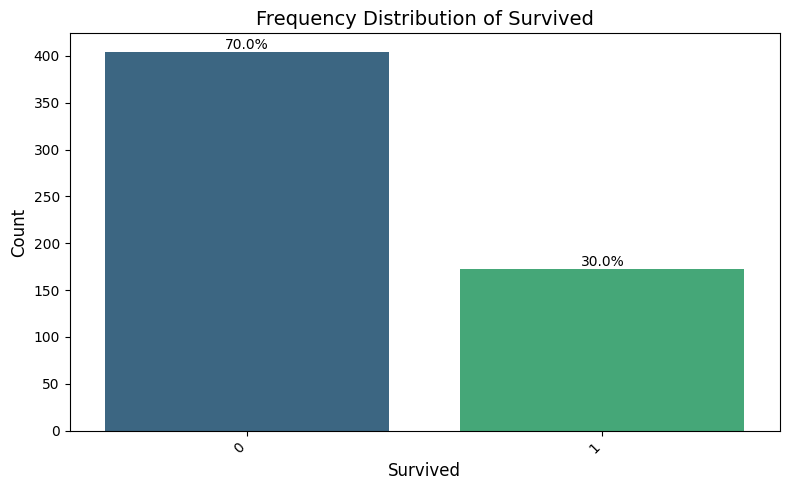

In [104]:
# 5-B  Categorical frequency bar charts with % labels
# inspector.plot_categorical(column_names=['Sex', 'Pclass', 'Embarked', 'Survived'])

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd # Ensure pandas is imported

columns_to_plot = ['Sex', 'Pclass', 'Embarked', 'Survived']

print("--- Plotting Categorical Frequency Bar Charts ---")

for col in columns_to_plot:
    if col in inspector.df.columns:
        plt.figure(figsize=(8, 5))
        ax = sns.countplot(data=inspector.df, x=col, palette='viridis')
        plt.title(f'Frequency Distribution of {col}', fontsize=14)
        plt.xlabel(col, fontsize=12)
        plt.ylabel('Count', fontsize=12)

        # Add percentage labels on top of bars
        total = len(inspector.df[col].dropna())
        for p in ax.patches:
            percentage = '{:.1f}%'.format(100 * p.get_height()/total)
            x = p.get_x() + p.get_width() / 2
            y = p.get_height()
            ax.annotate(percentage, (x, y), ha='center', va='bottom', fontsize=10, color='black')

        plt.xticks(rotation=45, ha='right')
        plt.tight_layout()
        plt.show()
    else:
        print(f"Column '{col}' not found. Skipping plotting.")

In [105]:
# Num–Num: Scatter with OLS trendline
inspector.plot_relationship('Age', 'Fare')

In [106]:
# Cat–Num: Box plot with individual points
inspector.plot_relationship('Pclass', 'Fare')

In [107]:
# Cat–Num: Survival by Sex
inspector.plot_relationship('Sex', 'Survived')

In [108]:
# Cat–Cat: Grouped bar — Embarked × Pclass
inspector.plot_relationship('Embarked', 'Pclass')


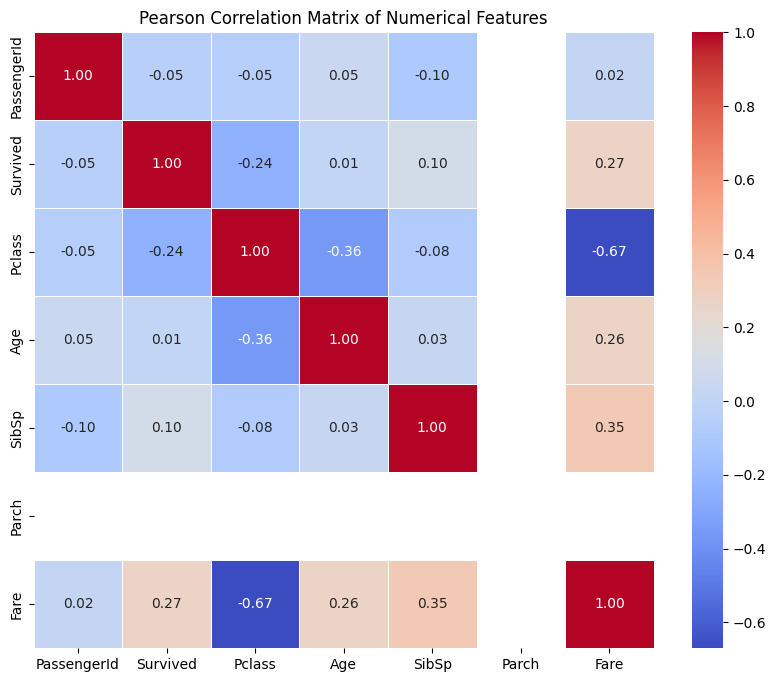

In [110]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate the Pearson correlation matrix for numerical columns only
correlation_matrix = inspector.df.select_dtypes(include=['number']).corr(method='pearson')

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Pearson Correlation Matrix of Numerical Features')
plt.show()

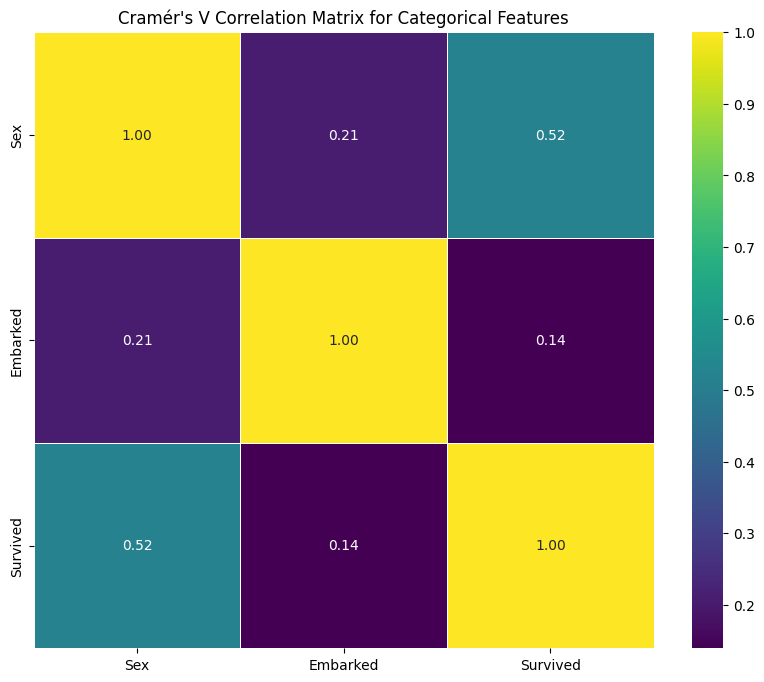

In [112]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

def cramers_v(x, y):
    confusion_matrix = pd.crosstab(x, y)
    chi2 = chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()
    phi2 = chi2 / n
    r, k = confusion_matrix.shape
    phi2corr = max(0, phi2 - ((k-1)*(r-1))/(n-1))
    rcorr = r - ((r-1)**2)/(n-1)
    kcorr = k - ((k-1)**2)/(n-1)
    return np.sqrt(phi2corr / min( (kcorr-1), (rcorr-1)))

from scipy.stats import chi2_contingency

# Select only categorical columns from the DataFrame
categorical_cols = inspector.df.select_dtypes(include='object').columns.tolist()

# Ensure 'Survived' (if treated as categorical) is included, and exclude other non-categorical
# For Titanic, 'Survived' is often treated as categorical for correlation with other categories
if 'Survived' in inspector.df.columns and 'Survived' not in categorical_cols:
    categorical_cols.append('Survived')

# Remove 'Name' if still present as it's typically unique and not useful for categorical correlation
if 'Name' in categorical_cols:
    categorical_cols.remove('Name')

# Create an empty DataFrame to store Cramér's V results
cramers_v_matrix = pd.DataFrame(index=categorical_cols, columns=categorical_cols)

# Calculate Cramér's V for all pairs of categorical columns
for col1 in categorical_cols:
    for col2 in categorical_cols:
        if col1 == col2:
            cramers_v_matrix.loc[col1, col2] = 1.0
        else:
            # Drop rows where either column has NaN for accurate calculation
            temp_df = inspector.df[[col1, col2]].dropna()
            if not temp_df.empty:
                cramers_v_matrix.loc[col1, col2] = cramers_v(temp_df[col1], temp_df[col2])
            else:
                cramers_v_matrix.loc[col1, col2] = np.nan # No data to calculate

# Convert to float for heatmap visualization
cramers_v_matrix = cramers_v_matrix.astype(float)

# Plot the heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(cramers_v_matrix, annot=True, cmap='viridis', fmt=".2f", linewidths=.5)
plt.title("Cramér's V Correlation Matrix for Categorical Features")
plt.show()


/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2922: RuntimeWarning:

invalid value encountered in divide

/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2923: RuntimeWarning:

invalid value encountered in divide

/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2922: RuntimeWarning:

invalid value encountered in divide

/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2923: RuntimeWarning:

invalid value encountered in divide

/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2922: RuntimeWarning:

invalid value encountered in divide

/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2923: RuntimeWarning:

invalid value encountered in divide

/usr/local/lib/python3.12/dist-packages/scipy/stats/_axis_nan_policy.py:579: ConstantInputWarning:

Each of the input arrays is constant; the F statistic is not defined or infinite

/usr/local/lib/pytho

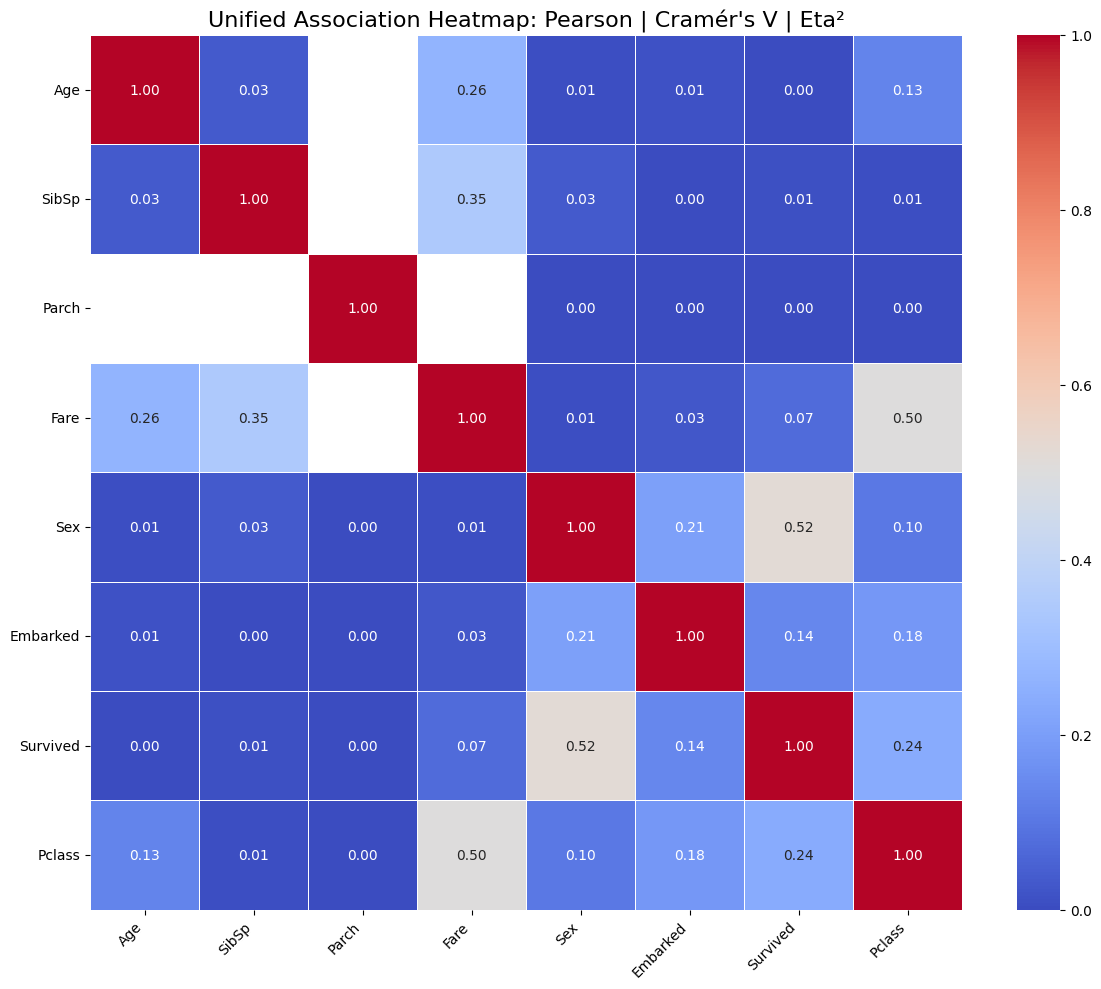

In [114]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import chi2_contingency, f_oneway

# Function to calculate Cramér's V (for Categorical-Categorical)
def cramers_v(x, y):
    confusion_matrix = pd.crosstab(x, y)
    chi2 = chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()
    phi2 = chi2 / n
    r, k = confusion_matrix.shape
    phi2corr = max(0, phi2 - ((k-1)*(r-1))/(n-1))
    rcorr = r - ((r-1)**2)/(n-1)
    kcorr = k - ((k-1)**2)/(n-1)
    # Handle cases where min((kcorr-1), (rcorr-1)) might be zero or negative
    denominator = min((kcorr - 1), (rcorr - 1))
    if denominator <= 0:
        return 0.0
    return np.sqrt(phi2corr / denominator)

# Function to calculate Eta-squared (for Categorical-Numerical)
def calculate_eta_squared(categorical_series, numerical_series):
    try:
        temp_df = pd.DataFrame({'cat': categorical_series, 'num': numerical_series}).dropna()
        if temp_df.empty:
            return np.nan

        groups = [temp_df['num'][temp_df['cat'] == cat].values for cat in temp_df['cat'].unique()]
        groups = [group for group in groups if len(group) > 0] # Filter out empty groups

        if len(groups) < 2: # ANOVA requires at least 2 groups
            return 0.0

        # Perform one-way ANOVA
        f_statistic, p_value = f_oneway(*groups)

        # Calculate Sum of Squares (SS)
        ss_total = ((temp_df['num'] - temp_df['num'].mean()) ** 2).sum()
        ss_between = sum([len(group) * ((np.mean(group) - temp_df['num'].mean()) ** 2) for group in groups])

        if ss_total == 0:
            return 0.0

        eta_squared = ss_between / ss_total
        return eta_squared
    except Exception as e:
        return np.nan

# Get all relevant columns, excluding identifiers
all_dataset_cols = inspector.df.columns.tolist()
if 'PassengerId' in all_dataset_cols:
    all_dataset_cols.remove('PassengerId')
if 'Name' in all_dataset_cols:
    all_dataset_cols.remove('Name')

# Classify columns into numerical and categorical based on current dtypes
numeric_cols_initial = inspector.df[all_dataset_cols].select_dtypes(include=['number']).columns.tolist()
categorical_cols_initial = inspector.df[all_dataset_cols].select_dtypes(include='object').columns.tolist()

# Special handling for 'Survived' and 'Pclass': often treated as categorical for association analysis
final_numeric_cols = [col for col in numeric_cols_initial if col not in ['Survived', 'Pclass']]
final_categorical_cols = categorical_cols_initial + [col for col in ['Survived', 'Pclass'] if col in all_dataset_cols]

# Remove duplicates and maintain order (numerical first, then categorical)
final_ordered_cols = final_numeric_cols + [col for col in final_categorical_cols if col not in final_numeric_cols]

# Initialize a DataFrame for the combined correlation matrix
unified_corr_matrix = pd.DataFrame(index=final_ordered_cols, columns=final_ordered_cols, dtype=float)

# Fill the matrix with appropriate association measures
for i, col1 in enumerate(final_ordered_cols):
    for j, col2 in enumerate(final_ordered_cols):
        if i == j:
            unified_corr_matrix.loc[col1, col2] = 1.0 # Self-correlation is 1
        elif i > j: # Only calculate for upper triangle and then mirror
            temp_df_pair = inspector.df[[col1, col2]].dropna()

            if temp_df_pair.empty:
                corr_val = np.nan
            else:
                is_col1_num = col1 in final_numeric_cols
                is_col2_num = col2 in final_numeric_cols
                is_col1_cat = col1 in final_categorical_cols
                is_col2_cat = col2 in final_categorical_cols

                if is_col1_num and is_col2_num:
                    # Numerical-Numerical: Pearson Correlation
                    corr_val = temp_df_pair[col1].corr(temp_df_pair[col2], method='pearson')
                elif is_col1_cat and is_col2_cat:
                    # Categorical-Categorical: Cramér's V
                    corr_val = cramers_v(temp_df_pair[col1], temp_df_pair[col2])
                elif (is_col1_cat and is_col2_num):
                    # Categorical-Numerical: Eta-squared
                    corr_val = calculate_eta_squared(temp_df_pair[col1], temp_df_pair[col2])
                elif (is_col1_num and is_col2_cat):
                    # Numerical-Categorical: Eta-squared (reversed logic, but result is symmetric)
                    corr_val = calculate_eta_squared(temp_df_pair[col2], temp_df_pair[col1])
                else:
                    corr_val = np.nan # Fallback, should not be reached with proper type classification

            unified_corr_matrix.loc[col1, col2] = corr_val
            unified_corr_matrix.loc[col2, col1] = corr_val # Mirror for symmetry

# Plot the heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(unified_corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title("Unified Association Heatmap: Pearson | Cramér's V | Eta²", fontsize=16)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [116]:
import pandas as pd
from sklearn.preprocessing import MinMaxScaler, StandardScaler, RobustScaler

# Identify numerical columns for scaling
numeric_cols = ['Age', 'SibSp', 'Parch', 'Fare']

# Ensure these columns exist in the DataFrame
numeric_cols_to_scale = [col for col in numeric_cols if col in inspector.df.columns]

if not numeric_cols_to_scale:
    print("No numerical columns found for scaling.")
else:
    print(f"Scaling numerical columns: {', '.join(numeric_cols_to_scale)}")

    # Min-Max Scaling
    minmax_scaler = MinMaxScaler()
    norm_minmax_df = inspector.df[numeric_cols_to_scale].copy()
    norm_minmax_df[numeric_cols_to_scale] = minmax_scaler.fit_transform(norm_minmax_df[numeric_cols_to_scale])

    # Standard Scaling (Z-score)
    standard_scaler = StandardScaler()
    norm_standard_df = inspector.df[numeric_cols_to_scale].copy()
    norm_standard_df[numeric_cols_to_scale] = standard_scaler.fit_transform(norm_standard_df[numeric_cols_to_scale])

    # Robust Scaling (IQR)
    robust_scaler = RobustScaler()
    norm_robust_df = inspector.df[numeric_cols_to_scale].copy()
    norm_robust_df[numeric_cols_to_scale] = robust_scaler.fit_transform(norm_robust_df[numeric_cols_to_scale])

    print('\nMin-Max sample:')
    display(norm_minmax_df.head())

    print('\nStandard (Z-score) sample:')
    display(norm_standard_df.head())

    print('\nRobust (IQR) sample:')
    display(norm_robust_df.head())

Scaling numerical columns: Age, SibSp, Parch, Fare

Min-Max sample:


,Age,SibSp,Parch,Fare
0,0.469388,0.5,0.0,0.118512
2,0.428571,0.0,0.0,0.236276
3,0.612245,0.5,0.0,0.868002
4,0.612245,0.0,0.0,0.131590
5,0.469388,0.0,0.0,0.138264



Standard (Z-score) sample:


,Age,SibSp,Parch,Fare
0,-0.153846,1.800735,0.0,-0.610509
2,-0.388065,-0.448235,0.0,-0.038394
3,0.665922,1.800735,0.0,3.030625
4,0.665922,-0.448235,0.0,-0.546978
5,-0.153846,-0.448235,0.0,-0.514553



Robust (IQR) sample:


,Age,SibSp,Parch,Fare
0,0.000000,1.0,0.0,-0.174923
2,-0.235294,0.0,0.0,0.717238
3,0.823529,1.0,0.0,5.503096
4,0.823529,0.0,0.0,-0.075851
5,0.000000,0.0,0.0,-0.025288


In [119]:
import pandas as pd
from sklearn.preprocessing import OrdinalEncoder, MinMaxScaler

# Identify categorical columns for encoding (excluding 'Name' as it's typically unique/identifier)
# Also, 'Survived' and 'Pclass' are often treated as categorical for encoding, even if numeric dtype
categorical_cols = inspector.df.select_dtypes(include='object').columns.tolist()
if 'Name' in categorical_cols:
    categorical_cols.remove('Name')

# Add 'Survived' and 'Pclass' if they are not already considered categorical
for col in ['Survived', 'Pclass']:
    if col in inspector.df.columns and col not in categorical_cols:
        categorical_cols.append(col)

# Ensure all columns to be encoded are actually present in the DataFrame
categorical_cols_to_encode = [col for col in categorical_cols if col in inspector.df.columns]

if not categorical_cols_to_encode:
    print("No categorical columns found for encoding.")
else:
    print(f"Encoding categorical columns: {', '.join(categorical_cols_to_encode)}")

    # Prepare DataFrame for One-Hot Encoding: ensure all intended columns are 'category' dtype
    df_for_onehot = inspector.df[categorical_cols_to_encode].copy()
    for col in ['Survived', 'Pclass']: # These are int64 but we want to treat them as categorical
        if col in df_for_onehot.columns and not pd.api.types.is_object_dtype(df_for_onehot[col]):
            df_for_onehot[col] = df_for_onehot[col].astype('category')

    # One-Hot Encoding
    # Now, pd.get_dummies will process all columns in df_for_onehot because they are object/category
    enc_onehot = pd.get_dummies(df_for_onehot, prefix=categorical_cols_to_encode)

    # Ordinal Encoding
    enc_ordinal_df = inspector.df[categorical_cols_to_encode].copy()
    for col in categorical_cols_to_encode:
        # Ensure the column is of type 'category' to handle order if desired, or object for simplicity
        # For simple ordinal encoding, directly fit_transform on object type works
        oe = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
        enc_ordinal_df[col] = oe.fit_transform(enc_ordinal_df[[col]])
    enc_ordinal = enc_ordinal_df

    # Uniform (0-1 Scaled) Encoding - typically applied after Ordinal Encoding
    enc_uniform_df = enc_ordinal.copy()
    for col in categorical_cols_to_encode:
        if col in enc_uniform_df.columns:
            # Scale the ordinally encoded values to 0-1 range
            min_val = enc_uniform_df[col].min()
            max_val = enc_uniform_df[col].max()
            if (max_val - min_val) > 0: # Avoid division by zero if all values are the same
                enc_uniform_df[col] = (enc_uniform_df[col] - min_val) / (max_val - min_val)
            else:
                enc_uniform_df[col] = 0.0 # If all values are the same, scale to 0
    enc_uniform = enc_uniform_df

    print('\nOne-Hot sample:')
    display(enc_onehot.head())

    print('\nOrdinal sample:')
    display(enc_ordinal.head())

    print('\nUniform (0–1 scaled) sample:')
    display(enc_uniform.head())

Encoding categorical columns: Sex, Embarked, Survived, Pclass

One-Hot sample:


,Sex_female,Sex_male,Embarked_C,Embarked_Q,Embarked_S,Survived_0,Survived_1,Pclass_1,Pclass_2,Pclass_3
0,False,True,False,False,True,True,False,False,False,True
2,True,False,False,False,True,False,True,False,False,True
3,True,False,False,False,True,False,True,True,False,False
4,False,True,False,False,True,True,False,False,False,True
5,False,True,False,True,False,True,False,False,False,True



Ordinal sample:


,Sex,Embarked,Survived,Pclass
0,1.0,2.0,0.0,2.0
2,0.0,2.0,1.0,2.0
3,0.0,2.0,1.0,0.0
4,1.0,2.0,0.0,2.0
5,1.0,1.0,0.0,2.0



Uniform (0–1 scaled) sample:


,Sex,Embarked,Survived,Pclass
0,1.0,1.0,0.0,1.0
2,0.0,1.0,1.0,1.0
3,0.0,1.0,1.0,0.0
4,1.0,1.0,0.0,1.0
5,1.0,0.5,0.0,1.0


In [121]:
# 8-C  Merged ML-ready DataFrame (robust numeric + ordinal categorical)
# The 'DataInspector' object does not have a 'create_normalized_data_df' method.
# We will manually construct the final DataFrame using previously generated scaled/encoded data.

# Retrieve the PassengerId from the current inspector.df (which has been filtered for outliers)
passenger_id_df = inspector.df[['PassengerId']].copy()

# Merge the robust scaled numerical features with the ordinal encoded categorical features
# Ensure indices are aligned, as all previous operations maintained the DataFrame index
final_df = pd.concat([passenger_id_df, norm_robust_df, enc_ordinal], axis=1)

display(final_df.head())
print('Shape:', final_df.shape)

,PassengerId,Age,SibSp,Parch,Fare,Sex,Embarked,Survived,Pclass
0,1,0.000000,1.0,0.0,-0.174923,1.0,2.0,0.0,2.0
2,3,-0.235294,0.0,0.0,0.717238,0.0,2.0,1.0,2.0
3,4,0.823529,1.0,0.0,5.503096,0.0,2.0,1.0,0.0
4,5,0.823529,0.0,0.0,-0.075851,1.0,2.0,0.0,2.0
5,6,0.000000,0.0,0.0,-0.025288,1.0,1.0,0.0,2.0


Shape: (577, 9)


In [122]:
# Instantiate the standalone plotter
PLT = PlottingMethods()

In [126]:
# 9-A  List all available chart methods by inspecting the object

# Get all attributes and methods of the PLT object
all_methods = dir(PLT)

# Filter out private/dunder methods and non-callable attributes to get public methods
public_methods = [method for method in all_methods if not method.startswith('_') and callable(getattr(PLT, method))]

# Create a DataFrame for better display
methods_info_df = pd.DataFrame({'Method Name': public_methods})

print("Available plotting methods in PlottingMethods object:")
display(methods_info_df)

Available plotting methods in PlottingMethods object:


,Method Name
0,generate_bar_chart
1,generate_histogram
2,generate_pie_chart


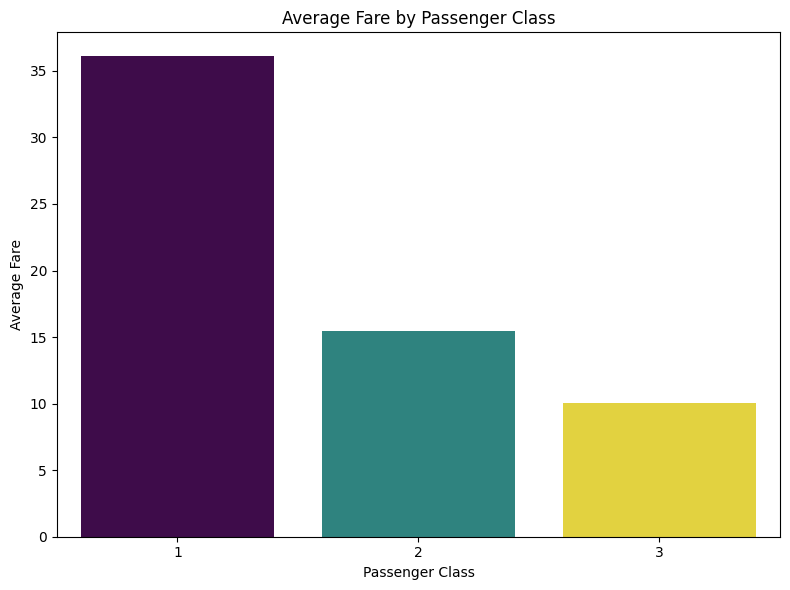

In [130]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Calculate the average Fare per Pclass
avg_fare_per_pclass = inspector.df.groupby('Pclass')['Fare'].mean().reset_index()

plt.figure(figsize=(8, 6))
sns.barplot(x='Pclass', y='Fare', data=avg_fare_per_pclass, palette='viridis', hue='Pclass', legend=False)
plt.title('Average Fare by Passenger Class')
plt.xlabel('Passenger Class')
plt.ylabel('Average Fare')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# The original lines below are commented out as we are now using matplotlib/seaborn directly.
# result = PLT.plot_bar_chart(x='Pclass', y='Fare',
#                              title='Average Fare by Passenger Class',
#                              data=inspector.df)
# print('Status:', result.get('status'))
# PLT.display_image(result)

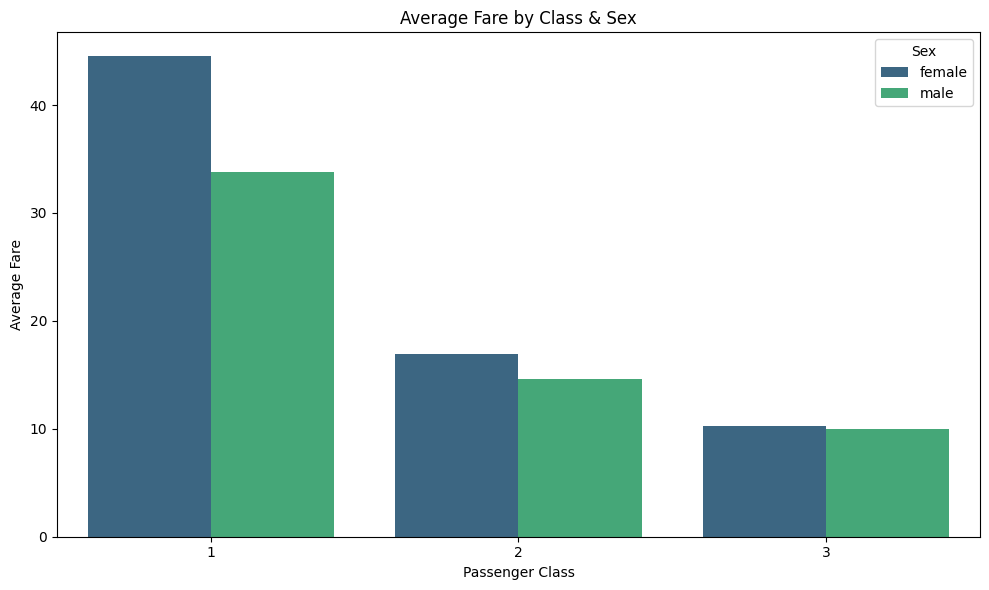

In [134]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Calculate the average Fare per Pclass and Sex
avg_fare_per_pclass_sex = inspector.df.groupby(['Pclass', 'Sex'])['Fare'].mean().reset_index()

plt.figure(figsize=(10, 6))
sns.barplot(x='Pclass', y='Fare', hue='Sex', data=avg_fare_per_pclass_sex, palette='viridis')
plt.title('Average Fare by Class & Sex')
plt.xlabel('Passenger Class')
plt.ylabel('Average Fare')
plt.xticks(rotation=0)
plt.legend(title='Sex')
plt.tight_layout()
plt.show()

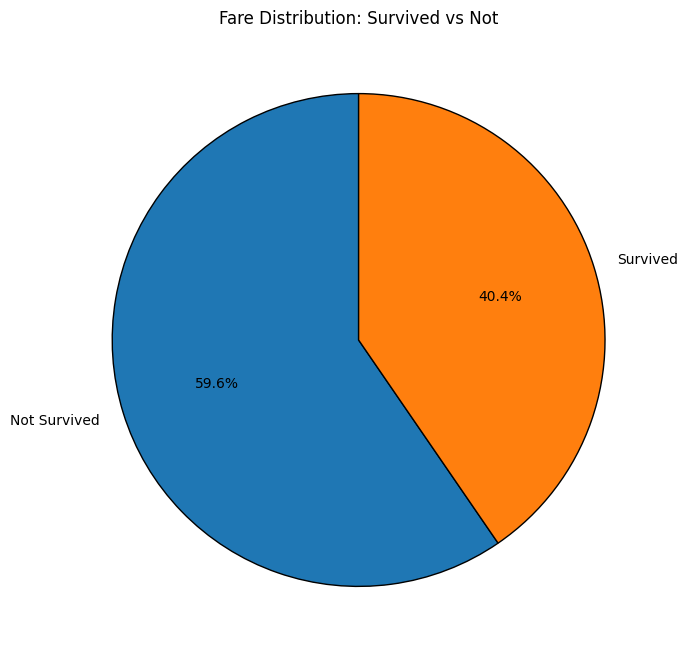

In [137]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Calculate the sum of Fare for 'Survived' and 'Not Survived'
survival_fare = inspector.df.groupby('Survived')['Fare'].sum()

plt.figure(figsize=(8, 8))
plt.pie(survival_fare, labels=['Not Survived', 'Survived'], autopct='%1.1f%%', startangle=90, wedgeprops={'edgecolor': 'black'})
plt.title('Fare Distribution: Survived vs Not')
plt.show()

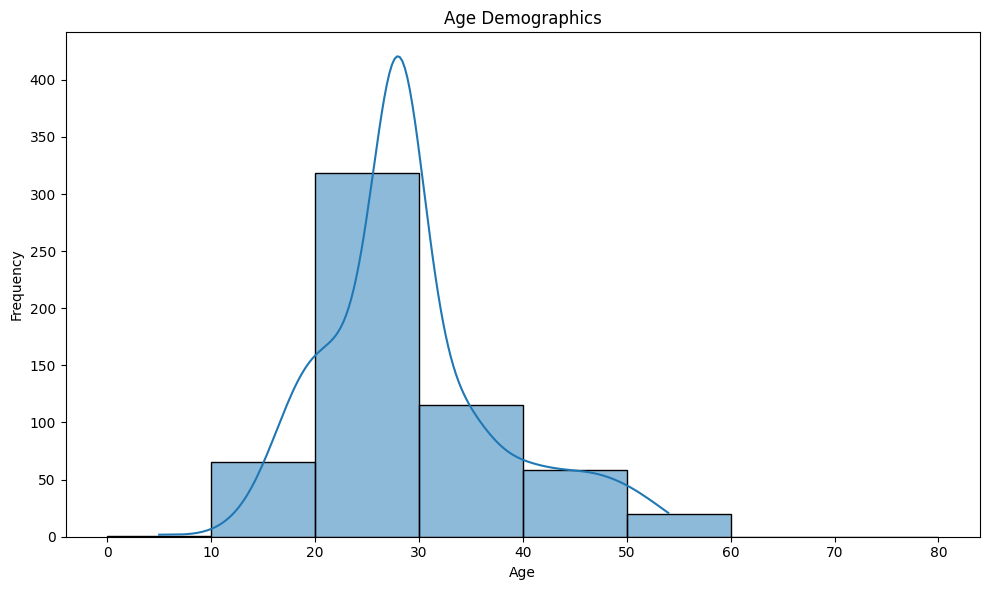

In [140]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Define the bins for the histogram
bins = [0, 10, 20, 30, 40, 50, 60, 70, 80]

plt.figure(figsize=(10, 6))
sns.histplot(inspector.df['Age'], bins=bins, kde=True, edgecolor='black')
plt.title('Age Demographics')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.xticks(bins)
plt.tight_layout()
plt.show()

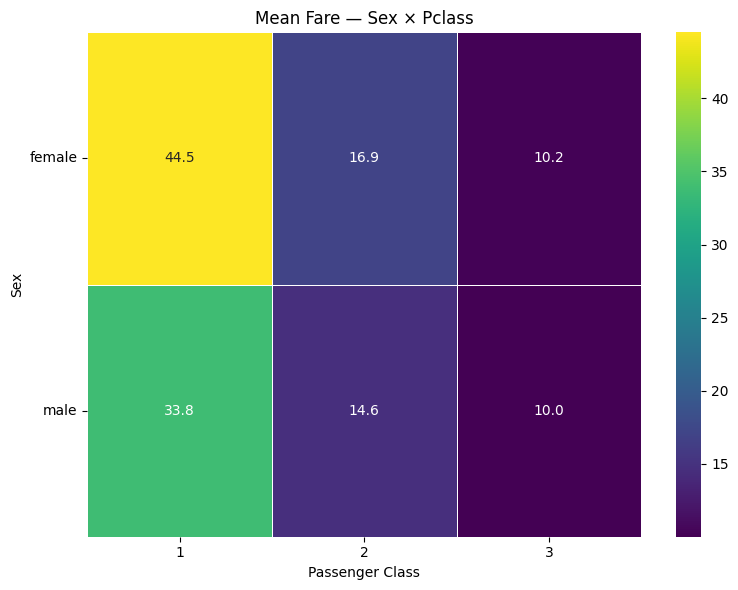

In [142]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# 9-F  Pivot heatmap: mean Fare by Sex × Pclass
# The original PLT.plot_heat_map is not available, using custom implementation

pivot_table_data = inspector.df.pivot_table(values='Fare',
                                           index='Sex',
                                           columns='Pclass',
                                           aggfunc='mean')

plt.figure(figsize=(8, 6))
sns.heatmap(pivot_table_data, annot=True, fmt=".1f", cmap="viridis", linewidths=.5)
plt.title('Mean Fare — Sex × Pclass')
plt.xlabel('Passenger Class')
plt.ylabel('Sex')
plt.xticks(rotation=0)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [144]:
import plotly.graph_objects as go
import pandas as pd

# 9-G  Sankey diagram: Embarked → Pclass flow (weighted by Fare)
# The original PLT.plot_sankey_diagram is not available, using custom implementation with Plotly.

# Prepare data for Sankey diagram
# Step 1: Create a dataframe for the links
# Ensure 'Pclass' is treated as a string for labels if it's currently numeric, to avoid confusion with indices
links_df = inspector.df.groupby(['Embarked', 'Pclass'])['Fare'].sum().reset_index()
links_df['Pclass_str'] = 'Pclass: ' + links_df['Pclass'].astype(str)

# Step 2: Define all unique nodes (Embarked locations and Pclass categories)
# Use unique values for Embarked and Pclass_str for labels
all_nodes = list(links_df['Embarked'].unique()) + list(links_df['Pclass_str'].unique())
node_labels = sorted(list(set(all_nodes)))

# Step 3: Create a mapping from node label to numerical index
label_to_index = {label: i for i, label in enumerate(node_labels)}

# Step 4: Map the source, target, and values for the links
source_indices = links_df['Embarked'].map(label_to_index).tolist()
target_indices = links_df['Pclass_str'].map(label_to_index).tolist()
link_values = links_df['Fare'].tolist()

# Create the Sankey diagram
fig = go.Figure(data=[go.Sankey(
    node=dict(
        pad=15,
        thickness=20,
        line=dict(color="black", width=0.5),
        label=node_labels,
        color="blue"
    ),
    link=dict(
        source=source_indices, # indices correspond to labels, e.g., 'Embarked' source
        target=target_indices, # indices correspond to labels, e.g., 'Pclass' target
        value=link_values,
        # Optional: Add colors based on source or target if desired
        # color=["rgba(0,0,255,0.2)" if s < len(links_df['Embarked'].unique()) else "rgba(255,0,0,0.2)" for s in source_indices]
    )
)])

fig.update_layout(title_text="Flow from Embarked Port to Passenger Class (Weighted by Fare)", font_size=10)
fig.show()


In [146]:
import plotly.express as px
import pandas as pd

# 9-H  Sunburst chart: Sex → Pclass hierarchy, sized by Fare
# The original PLT.plot_simple_sunburst_graph is not available, using custom implementation with Plotly Express.

# Prepare data for the sunburst chart
# The `path` argument expects a list of column names to define the hierarchy.
# The `values` argument specifies the column to aggregate for the size of segments.

fig = px.sunburst(inspector.df,
                    path=['Sex', 'Pclass'],
                    values='Fare',
                    title='Fare Hierarchy: Sex → Passenger Class')

fig.update_layout(margin = dict(t=50, l=0, r=0, b=0))
fig.show()
